In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
data = 'BTC-market-analysis_2021-25.csv'
pd.set_option('display.max_rows', 100)
df = pd.read_csv(data)

In [3]:
return_window = 60

In [4]:
df.columns

Index(['date', 'adj close', 'close', 'high', 'low', 'open', 'volume',
       'sp500_close', 'gold_close', 'dxy_close', 'fng_score', 'hash_rate',
       'google_trends_score', 'btc_return', 'btc_log_return', 'sp500_return',
       'gold_return', 'dxy_return', 'btc_vol_7d', 'btc_vol_14d',
       'target_return', 'target_direction'],
      dtype='str')

In [5]:
# df.dropna(inplace = True)
date = np.array(pd.to_datetime(df['date']))

In [6]:
btc_log_return_full = np.array(df['btc_log_return'].shift(-return_window).rolling(window=return_window).sum())

In [7]:
# df['xau_log_tmp'] = df['gold_return'].shift(-90).rolling(window=90).sum()

In [8]:
## CALCULATE LOG RETURNS FOR GOLD WITH 90 DAY WINDOW

df['xau_log_return'] = np.log(1 + df['gold_return'])
xau_log_return_full = np.array(df['xau_log_return'].shift(-return_window).rolling(window=return_window).sum())

In [9]:
## CALCULATE LOG RETURNS FOR S&P500 WITH 90 DAY WINDOW

sp500_log_tmp = np.array(df['sp500_return'])
sp500_log_tmp = np.log(1 + sp500_log_tmp)
df['sp500_log_tmp'] = sp500_log_tmp
sp500_log_return_full = np.array(df['sp500_log_tmp'].shift(-return_window).rolling(window=return_window).sum())

In [10]:
# i = 0
# xau_log_return = []
# btc_log_return = []
# new_date = []
# xau_log_return_90 = []
# sp500_log_return_90 = []
# while (i < len(xau_log_tmp)):
#     sp500_log_return_90.append(sp500_log_return_full[i])
#     xau_log_return_90.append(xau_log_return_full[i])        
#     btc_log_return.append(btc_log_tmp[i])
#     new_date.append(date[i])
#     i += 30

In [11]:
interval = 20
new_date = date[return_window::interval]
xau_log_return_split = xau_log_return_full[return_window::interval]
sp500_log_return_split = sp500_log_return_full[return_window::interval]
btc_log_return_split = btc_log_return_full[return_window::interval]

In [12]:
# df['xau_log_return'] = np.log(df['gold_return'].shift(-14).rolling(window=14).sum() / df['close']
len(btc_log_return_split)

89

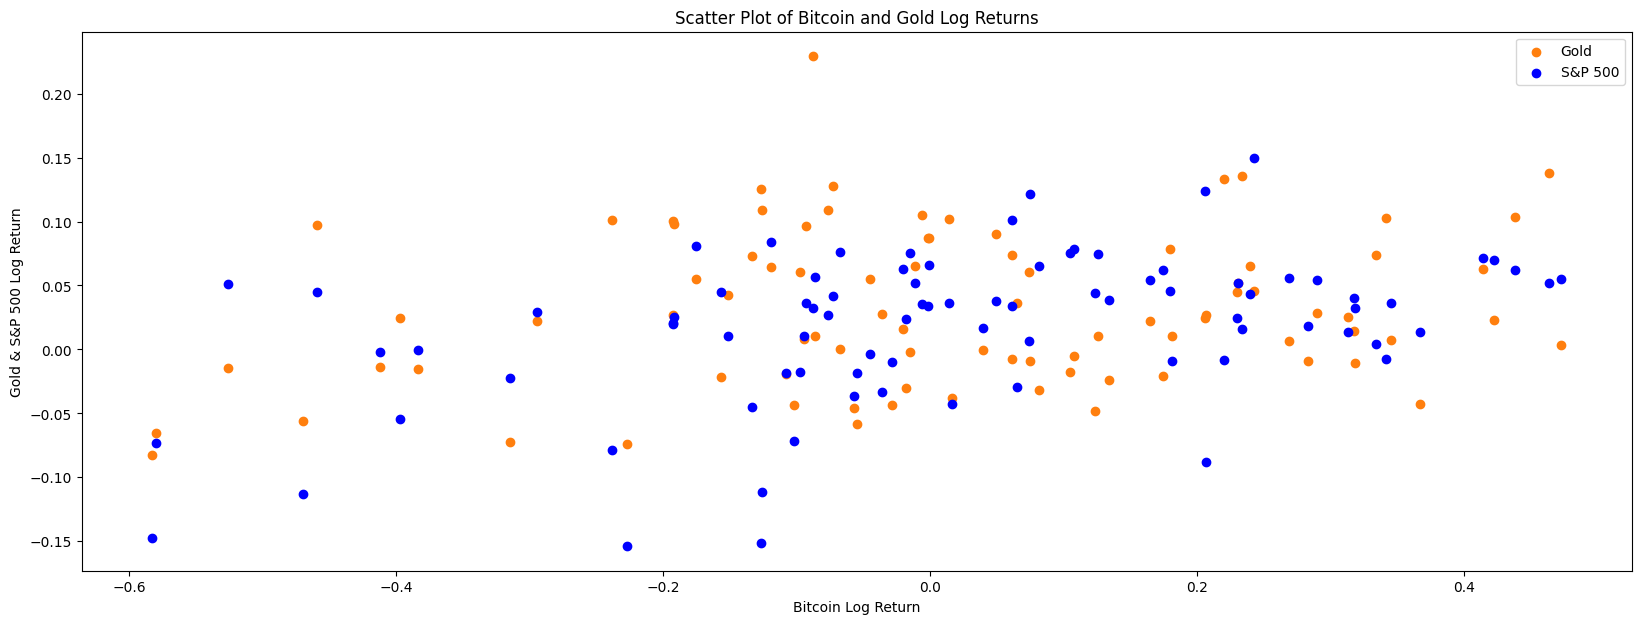

In [99]:
fig, ax = plt.subplots(figsize=(20, 7))
ax.scatter(btc_log_return_split, xau_log_return_split, color='C1', label='Gold')
ax.scatter(btc_log_return_split, sp500_log_return_split, color='blue', label='S&P 500')
ax.set_xlabel('Bitcoin Log Return')
ax.set_ylabel('Gold & S&P 500 Log Return')
ax.set_title('Scatter Plot of Bitcoin and Gold Log Returns')
ax.legend()
plt.show()


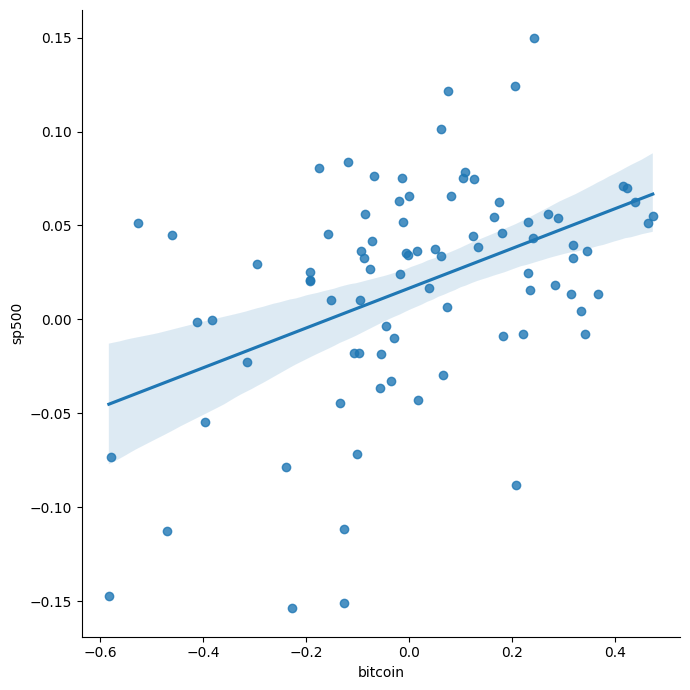

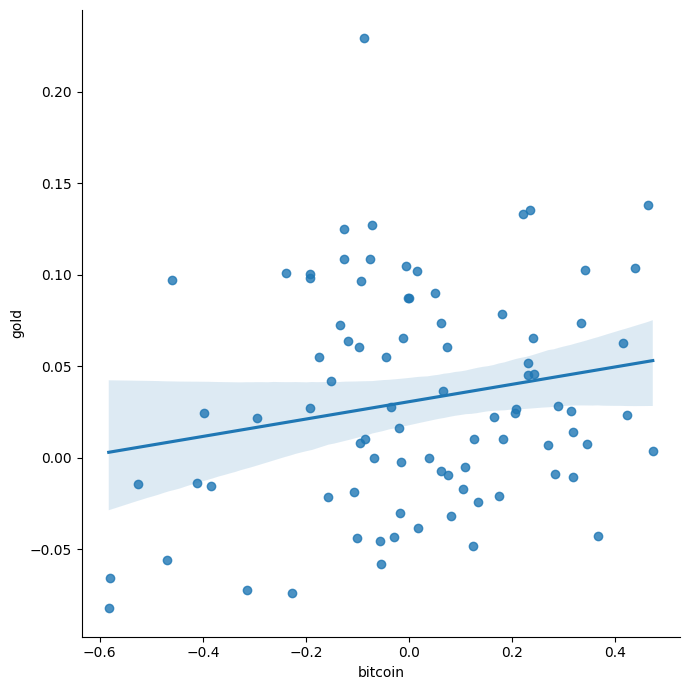

In [98]:

# m, b = np.polyfit(sp500_log_return_split, xau_log_return_split, 1)

# fig, ax = plt.subplots(figsize=(20, 8))
# ax.scatter(sp500_log_return_split, xau_log_return_split, alpha=0.6, color='orange')

# # Desenhar a linha de tendência
# ax.plot(sp500_log_return_split, m*sp500_log_return_split + b, color='red', 
#         linewidth=2, label=f'Tendência (Beta: {m:.2f})')

# ax.set_title("Análise de Sensibilidade: S&P 500 vs Gold")
# ax.set_xlabel("S&P 500 Log Return")
# ax.set_ylabel("Gold Log Return")
# ax.legend()
# ax.grid(True, alpha=0.3)




df_plot = pd.DataFrame({
    'sp500': sp500_log_return_split,
    'gold': xau_log_return_split,
    'bitcoin': btc_log_return_split
})

# 2. Chamar o lmplot passando os nomes das colunas e o DataFrame
sns.lmplot(x='bitcoin', y='sp500', data=df_plot, height=7, aspect=1)
sns.lmplot(x='bitcoin', y='gold', data=df_plot, height=7, aspect=1)

In [14]:
df.dropna(inplace = True)

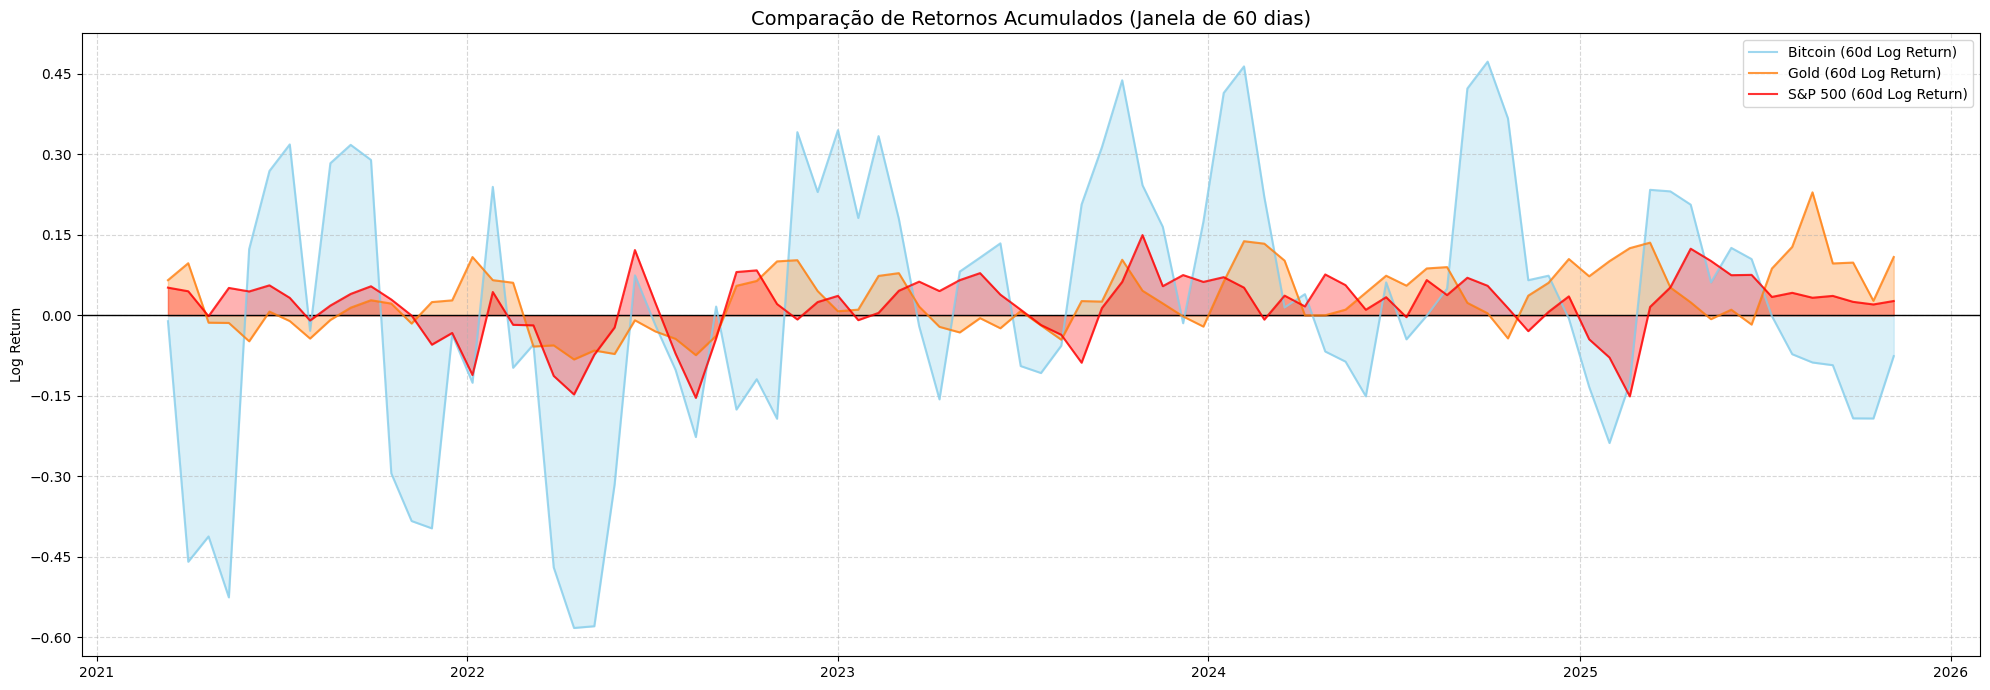

In [74]:
fig, ax = plt.subplots(figsize=(20, 7))

# Melhorar o grid e labels
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.set_title(f'Comparação de Retornos Acumulados (Janela de {return_window} dias)', fontsize=14)
ax.set_ylabel('Log Return')

ax.axhline(y=0, color='black', linewidth=1)

# Usar o locator que aprendeste
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=10)) 

pairs = [(btc_log_return_split, 'skyblue', 'Bitcoin'), (xau_log_return_split, 'C1', 'Gold'), (sp500_log_return_split, 'red', 'S&P 500')]

for ret, col, name in pairs:    
    ax.plot(new_date, ret, color=col, label=f'{name} ({return_window}d Log Return)', alpha=0.8)
    ax.fill_between(new_date, 0, ret, interpolate=True, color=col, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()